In [1]:
import os
import numpy as np
import sympy as sp
import pylbo as pb
import pylbo.gimli as gl
import matplotlib.pyplot as plt
from pathlib import Path

## Define equilibrium

In [2]:
var = gl.Variables()
density = 1.0 - (1.0 - var.delta)*(var.x/var.r0)**2
B2field = (
    var.j0 * var.x * (var.x ** 4 - 3.0 * var.x ** 2 + 3.0) / 6.0
)
B3field = 1.0
v2field = 0
v3field = 0
# force balance: determine pressure from force balance and control pressure on cylinder edge
dp = sp.simplify(-sp.diff(B2field**2 + B3field**2, var.x) / 2 - B2field**2 / var.x)
p = sp.integrate(dp, var.x)
pressure = p - p.subs(var.x, var.r0) + 5e-5
temperature = sp.simplify(pressure / density)

heatcool = {
    "cooling_curve": "Colgan_DM",
    "force_thermal_balance": True,  # cannot go with user-specified heating
    "ncool": 12000,
}
conduction = {
    "parallel_conduction": True,
}

In [3]:
display(sp.simplify(p))
balance = -sp.diff(p, var.x) -sp.diff(B2field**2+B3field**2, var.x)/2 - B2field**2/var.x
display(sp.simplify(balance))

j_0**2*x**2*(-0.0166666666666667*x**8 + 0.104166666666667*x**6 - 0.277777777777778*x**4 + 0.375*x**2 - 0.25)

j_0**2*x**5*(5.55111512312578e-17*x**2 + 2.22044604925031e-16)

In [4]:
# choosing parameters
r0 = 1.0
delta = 0.2
j0 = 0.5
mval = 5
kval = 1.0

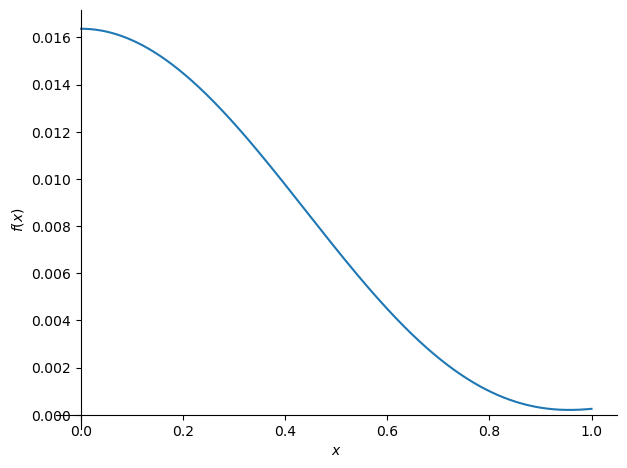

In [5]:
# plotting temperature to make sure it remains positive
sp.plot(temperature.subs({var.r0:r0, var.delta:delta, var.j0:j0}), (var.x, 0, 1.0))

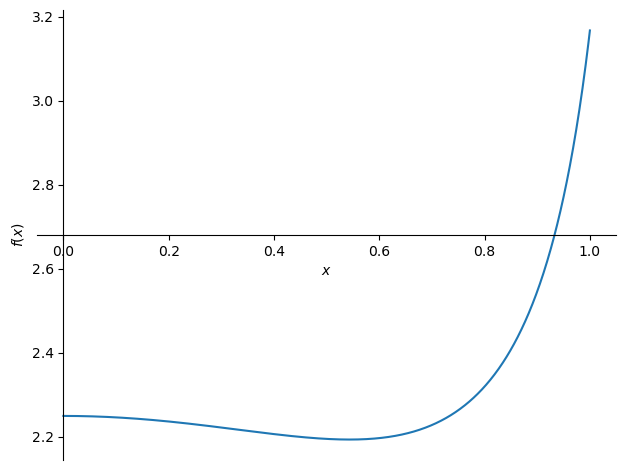

2.19376977189251

In [6]:
# plotting Alfvén frequency range. In this case, we need an inflection point to have
# discrete Alfvén modes clustering to the continuum edge.
m, k = sp.symbols("m k")
omegaA = (m*B2field/var.x + k*B3field)/sp.sqrt(density)
omegaA = omegaA.subs({var.r0: r0, var.delta: delta, var.j0: j0, m: mval, k: kval})
sp.plot(omegaA, (var.x, 0, 1.0))

# determining the cluster frequency that is expected to be close to that of the discrete Alfvén mode
dom = sp.diff(omegaA, var.x)
sols = sp.solve(dom, var.x)
omegaA.subs(var.x, sols[-2])
display(omegaA.subs(var.x, sols[-2]))

In [7]:
equil = gl.Equilibrium(var, density, v2field, v3field, temperature, B02=B2field, B03=B3field, heatcool=heatcool)

## Create Legolas files

In [8]:
if not os.path.exists("./legolas/"):
    os.system("mkdir -p ./legolas/")

legolas_config = {
    "geometry": "cylindrical",
        "x_start": 0.025,
        "x_end": 1.0,
        "gridpoints": 500,
        "solver": "QR-cholesky",
        "parameters": {"k2": 5.0, "k3": 1.0, "j0": j0, "delta": delta, "r0": r0},
        "equilibrium_type": "user_defined",
        "boundary_type": "wall_weak",
        "physics_type": "mhd",
        "parallel_conduction": True,
        "basename_datfile": "discrete_alfven",
        "output_folder": "./output/",
        "write_derived_eigenfunctions": True,
        "write_eigenfunctions": True,
        "show_results": False,
        "unit_density": 6e-15,
        "unit_magneticfield": 25.0,
        "unit_length": 1.0e8,
        "He_abundance": 0.1,
}
legolas = gl.Legolas(equil, legolas_config)
parfiles = legolas.parfile(loc="./legolas/")
legolas.user_module(loc="./legolas/")

2026-09-22 12:53:25,008 - |WARNING | Setting 'radiative_cooling' to True based on presence of heatcool.


2026-09-22 12:53:25,021 - |INFO    | parfiles generated and saved to /Users/nicolas/codes/legolas/notebooks/legolas/parfiles


In the `legolas` folder, run
```
setuplegolas.py
buildlegolas.sh
```
to compile Legolas and
```
./legolas -i parfiles/legolas_config.par
```
to obtain the eigenmodes and corresponding perturbations.

2026-09-22 12:54:41,937 - |INFO    | Legolas v2.3.1
2026-09-22 12:54:41,938 - |INFO    | file loaded : legolas/output/discrete_alfven.dat
2026-09-22 12:54:41,938 - |INFO    | gridpoints  : 500
2026-09-22 12:54:41,938 - |INFO    | geometry    : cylindrical in (0.025, 1.0)
2026-09-22 12:54:41,939 - |INFO    | equilibrium : user_defined
2026-09-22 12:54:41,942 - |INFO    | state vector: ['rho' 'v1' 'v2' 'v3' 'T' 'a1' 'a2' 'a3']
2026-09-22 12:54:41,942 - |INFO    | basis functions: {np.str_('rho'): 'quadratic', np.str_('v1'): 'cubic', np.str_('v2'): 'quadratic', np.str_('v3'): 'quadratic', np.str_('T'): 'quadratic', np.str_('a1'): 'quadratic', np.str_('a2'): 'cubic', np.str_('a3'): 'cubic'}
2026-09-22 12:54:41,944 - |INFO    | eigenfunctions present in datfile
2026-09-22 12:54:41,945 - |INFO    | derived eigenfunctions present in datfile
2026-09-22 12:54:41,945 - |INFO    | ---------------------------------------------------------------------------


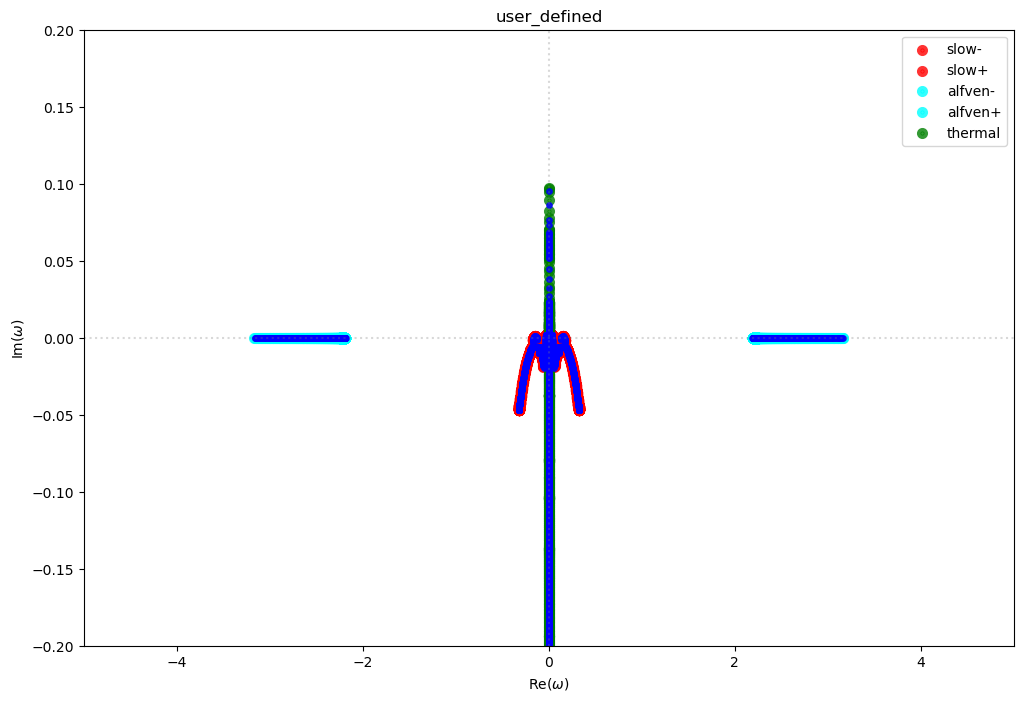

'Frequency: '

np.complex128(2.1846324319287937+1.939843567086106e-07j)

'Period: '

np.complex128(2.8760835073899202-2.553817296068884e-07j)

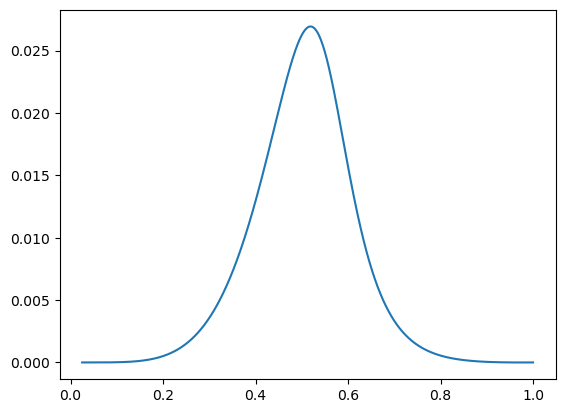

In [10]:
ds = pb.load(Path("legolas/output/discrete_alfven.dat"))

p = pb.plot_spectrum(ds)
p.ax.set_xlim(-5, 5)
p.ax.set_ylim(-0.2, 0.2)
p.add_continua(interactive=False)
p.show()

### displaying the modes:
### for thermal mode:
# omega = ds.get_omega_max(real=False, re_range=(-1,1))
### for discrete Alfvén mode:
omega = ds.get_eigenfunctions(ev_guesses=2.0)[0]["eigenvalue"]
display("Frequency: ", omega)
display("Period: ", 2 * np.pi / omega)

efs = ds.get_eigenfunctions(ev_guesses=omega)[0]
plt.figure()
plt.plot(ds.ef_grid, efs["T"].real)
plt.show()

## Prepare mode for MPI-AMRVAC

In the `legolas` folder, run `python pylbo_wrapper.py -i output/tearing.dat` and select the tearing mode. Then press `j` to save the indices of the selected mode to a `.npy` file. The saved index is used to get the eigenvalue from the datfile. Alternatively, check the value of the tearing frequency and assign that value to the `ev_guess` key in the dictionary.

In [11]:
if not os.path.exists("./amrvac/"):
    os.system("mkdir -p ./amrvac/")

lam2 = 2.0 * np.pi
lam3 = 2.0 * np.pi / legolas.config["parameters"]["k3"]
file = "./legolas/output/discrete_alfven.dat"
### if using saved indices:
# mode = './legolas/discrete_alfven.npy'
# indices = np.load(mode)
ds = pb.load(file)
amrvac_config = {
    "geometry": legolas.config["geometry"],
    "equilibrium": equil,
    "datfile": file,
    "physics_type": "mhd",
    "ev_guess": [2, 0.2j],
    "weights": [0.7, 0.3],
    "complex_factor": [1, np.sqrt(2) / 2 * (1 + 1j)],
    "quantity": "rho0",
    "percentage": 0.02,
    "dim": 3,
    "u1_bounds": [0.0, legolas.config["x_end"]],
    "u2_bounds": [0, 1],
    "u3_bounds": [0, lam3],
    "parameters": legolas.config["parameters"],
    "save_analytics": True,
    "parfile": {
        "base_filename": "",
        "autoconvert": True,
        "convert_type": "vtuBCCmpi", # this will be overwritten to dat_generic_mpi, which saves the full fields in a second datfile in the case of split fields
        "nwauxio": 11,
        "saveprim": True,
        "base_filename": "output/discrete_alfven_",
        "typefilelog": "special",
        "ditsave_log": 10,
        "dtsave_dat": 0.04,
        "dtmin": 1e-10,
        "time_max": 60,
        "time_stepper": "threestep",
        "flux_scheme": [20 * ["hll"]],
        "limiter": [20 * ["cada3"]],
        "check_small_values": False,
        "fix_small_values": False,
        "small_values_method": "replace",
        "small_pressure": 1e-14,
        "small_density": 1e-12,
        "typesourcesplit": "sfs",
        "B0field": True,
        "B0field_forcefree": False,
        "has_equi_rho_and_p": True,
        "mhd_equi_thermal": True,
        "He_abundance": 0.1,
        "typeboundary_min2": [8 * ["periodic"]],
        "typeboundary_max2": [8 * ["periodic"]],
        "typeboundary_min3": [8 * ["periodic"]],
        "typeboundary_max3": [8 * ["periodic"]],
        "typeboundary_min1": [8 * ["pole"]],
        "typeboundary_max1": [
            8 * ["special"]
        ],  # to be defined in mod_usr.t through 'usr_special_bc => specialbound_usr'
        "domain_nx1": 256,
        "domain_nx2": 256,
        "domain_nx3": 128,
        "block_nx1": 16,
        "block_nx2": 16,
        "block_nx3": 16,
        "refine_max_level": 1,
        "typecourant": "maxsum",
        "courantpar": 0.8,
        "mhd_radiative_cooling": True, 
        "tc_perpendicular": False, 
        "mhd_hyperbolic_tc": True, 
        "mhd_hyperbolic_tc_sat": True, 
    },
}
amrvac = gl.Amrvac(amrvac_config)
amrvac.prepare_legolas_data(loc="./amrvac/")

2026-09-22 12:55:02,141 - |INFO    | Legolas v2.3.1
2026-09-22 12:55:02,142 - |INFO    | file loaded : legolas/output/discrete_alfven.dat
2026-09-22 12:55:02,142 - |INFO    | gridpoints  : 500
2026-09-22 12:55:02,143 - |INFO    | geometry    : cylindrical in (0.025, 1.0)
2026-09-22 12:55:02,144 - |INFO    | equilibrium : user_defined
2026-09-22 12:55:02,146 - |INFO    | state vector: ['rho' 'v1' 'v2' 'v3' 'T' 'a1' 'a2' 'a3']
2026-09-22 12:55:02,147 - |INFO    | basis functions: {np.str_('rho'): 'quadratic', np.str_('v1'): 'cubic', np.str_('v2'): 'quadratic', np.str_('v3'): 'quadratic', np.str_('T'): 'quadratic', np.str_('a1'): 'quadratic', np.str_('a2'): 'cubic', np.str_('a3'): 'cubic'}
2026-09-22 12:55:02,147 - |INFO    | eigenfunctions present in datfile
2026-09-22 12:55:02,148 - |INFO    | derived eigenfunctions present in datfile
2026-09-22 12:55:02,149 - |INFO    | ---------------------------------------------------------------------------
2026-09-22 12:55:02,323 - |INFO    | Lego

'discrete_alfven'

## Generate MPI-AMRVAC files

In [12]:
amrvac.user_module(loc='./amrvac/')
amrvac.parfile(loc='./amrvac/', subdir=False)

2026-09-22 12:55:22,124 - |WARNING | Overriding 'convert_type' to 'dat_generic_mpi' to enable full variable saving. Use the 'aiconvert' option to convert to another format after the simulation.
2026-09-22 12:55:22,125 - |WARNING | 'coolcurve' is overridden by value in 'heatcool'.
2026-09-22 12:55:22,391 - |WARNING | Overriding 'convert_type' to 'dat_generic_mpi' to enable full variable saving. Use the 'aiconvert' option to convert to another format after the simulation.
2026-09-22 12:55:22,395 - |INFO    | parfiles generated and saved to /Users/nicolas/codes/legolas/notebooks/amrvac


['/Users/nicolas/codes/legolas/notebooks/amrvac/amrvac_config.par']

In the `amrvac` folder, run
```
setup.pl -d=3 -v=3
make -j X
mpirun -np X amrvac -i amrvac_config.par
```
where `X` is the number of cores to use.

## Simulation snapshots and analysis

In [15]:
import yt


def _velocity_x(field, data):
    r = data["amrvac", "r"] / data.ds.length_unit
    rhotot = (
        data["amrvac", "rho"] + (1.0 - (1.0 - 0.2) * (r) ** 2) * data.ds.density_unit
    ) # needed because of the split field
    vr = data["amrvac", "m1"] / rhotot
    vtheta = data["amrvac", "m2"] / rhotot
    theta = data["amrvac", "theta"]
    return vr * np.cos(theta) - vtheta * np.sin(theta)


def _velocity_y(field, data):
    r = data["amrvac", "r"] / data.ds.length_unit
    rhotot = (
        data["amrvac", "rho"] + (1.0 - (1.0 - 0.2) * (r) ** 2) * data.ds.density_unit
    ) # needed because of the split field
    vr = data["amrvac", "m1"] / rhotot
    vtheta = data["amrvac", "m2"] / rhotot
    theta = data["amrvac", "theta"]
    return vr * np.sin(theta) + vtheta * np.cos(theta)

yt : [INFO     ] 2026-09-22 12:57:06,682 Parameters: current_time              = 23.55
yt : [INFO     ] 2026-09-22 12:57:06,683 Parameters: domain_dimensions         = [256 256 128]
yt : [INFO     ] 2026-09-22 12:57:06,685 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-22 12:57:06,687 Parameters: domain_right_edge         = [1.         6.28318531 6.28318531]
yt : [INFO     ] 2026-09-22 12:57:06,689 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-09-22 12:57:06,987 Using full MHD energy for thermal pressure.
yt : [INFO     ] 2026-09-22 12:57:07,330 xlim = -1.000000 1.000000
yt : [INFO     ] 2026-09-22 12:57:07,331 ylim = -1.000000 1.000000
yt : [INFO     ] 2026-09-22 12:57:07,331 Setting origin='native' for polar geometry.
yt : [INFO     ] 2026-09-22 12:57:07,413 xlim = -1.000000 1.000000
yt : [INFO     ] 2026-09-22 12:57:07,438 ylim = -1.000000 1.000000
yt : [INFO     ] 2026-09-22 12:57:07,442 Making a fixed resolution buffer of (('amrvac', 


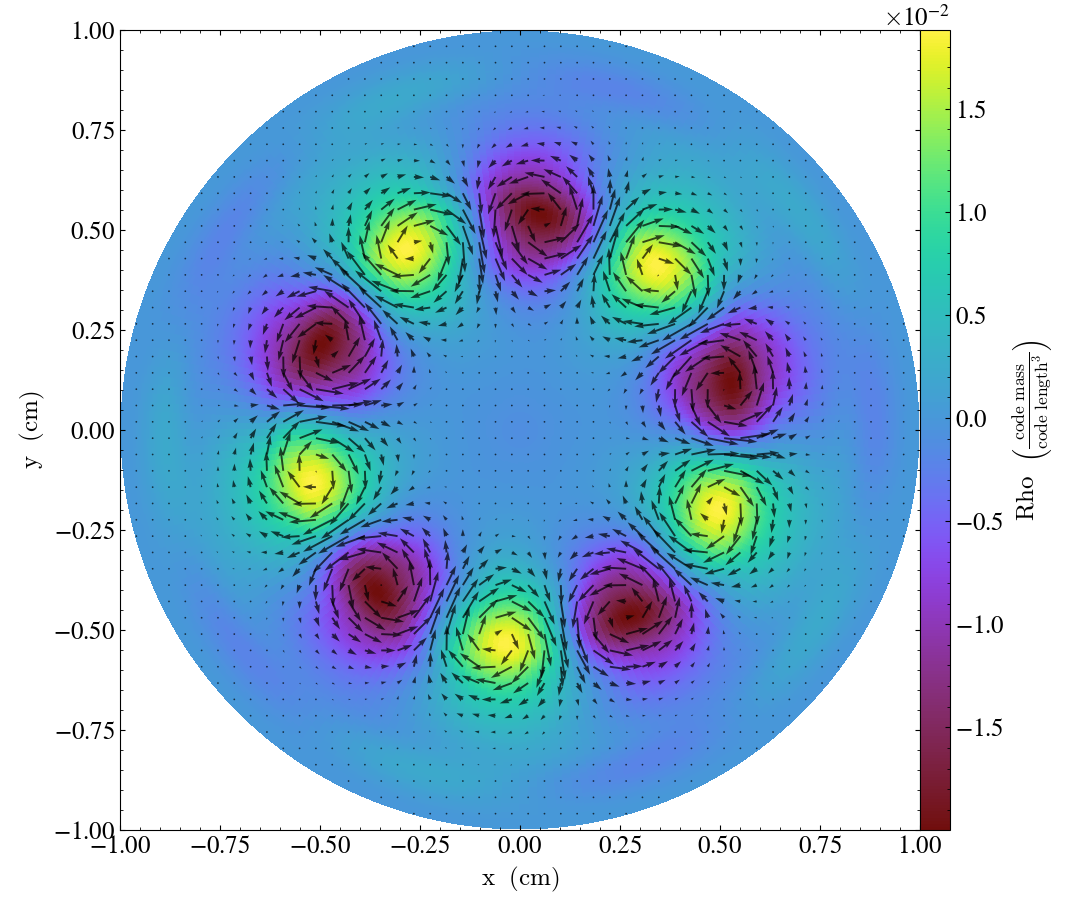

In [16]:
field = ("amrvac", "rho")
ds = yt.load("./amrvac/output/discrete_alfven_0471.dat")
ds.add_field(
    ("amrvac", "vx"),
    function=_velocity_x,
    sampling_type="cell",
)
ds.add_field(
    ("amrvac", "vy"),
    function=_velocity_y,
    sampling_type="cell",
)
slc = yt.SlicePlot(ds, 'z', field)
slc.annotate_quiver(("amrvac", "vx"), ("amrvac", "vy"), color="black", alpha=0.7)
slc.set_log(field, False)
slc

yt : [INFO     ] 2026-09-22 12:57:17,696 Parameters: current_time              = 23.55
yt : [INFO     ] 2026-09-22 12:57:17,697 Parameters: domain_dimensions         = [256 256 128]
yt : [INFO     ] 2026-09-22 12:57:17,699 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-22 12:57:17,701 Parameters: domain_right_edge         = [1.         6.28318531 6.28318531]
yt : [INFO     ] 2026-09-22 12:57:17,702 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-09-22 12:57:18,048 Using full MHD energy for thermal pressure.
yt : [INFO     ] 2026-09-22 12:57:18,290 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-09-22 12:57:18,290 ylim = 0.000000 6.283185
yt : [INFO     ] 2026-09-22 12:57:18,291 Setting origin='native' for polar geometry.
yt : [INFO     ] 2026-09-22 12:57:18,295 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-09-22 12:57:18,298 ylim = 0.000000 6.283185
yt : [INFO     ] 2026-09-22 12:57:18,299 Making a fixed resolution buffer of (('amrvac', 'rho


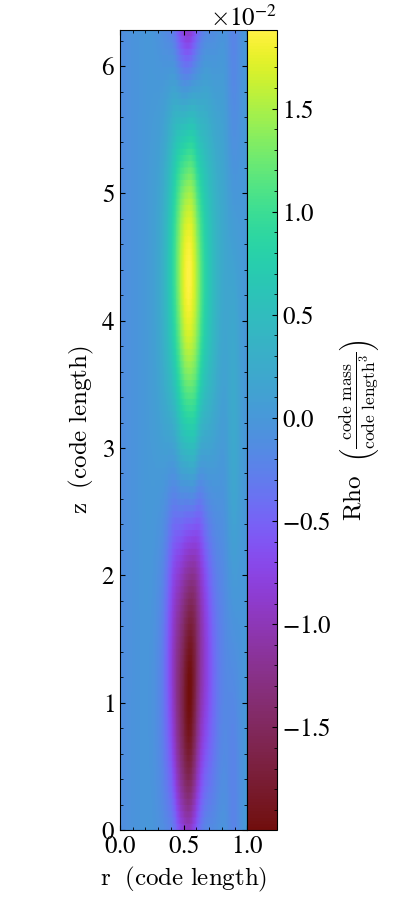

In [17]:
field = ("amrvac", "rho")
ds = yt.load(
    "./amrvac/output/discrete_alfven_0471.dat",
    unit_system="code",
)
slc = yt.SlicePlot(ds, "theta", field)
slc.set_log(field, False)
slc

In [18]:
# to read the MPI-AMRVAC analysis _c.log file, one requires a function like the following one:

def read_log(file_path):
    """
    Reads a log file with a header and creates a dictionary where keys are column names
    from the header and values are numpy arrays of the corresponding column data.

    Assumes the header is the first line, columns are space-separated, and all data is numeric.
    """

    with open(file_path, "r") as f:
        # Read header
        header = f.readline().strip().split()

        # Initialize dictionary with empty lists for each column
        data_dict = {col: [] for col in header}

        # Read data lines
        for line in f:
            values = line.strip().split()
            for i, val in enumerate(values):
                if val == "|":
                    break
                try:
                    data_dict[header[i]].append(float(val))
                except ValueError:
                    # If not numeric, append as string
                    data_dict[header[i]].append(val)

        # Convert lists to numpy arrays
        for key in data_dict:
            data_dict[key] = np.array(data_dict[key])

        return data_dict

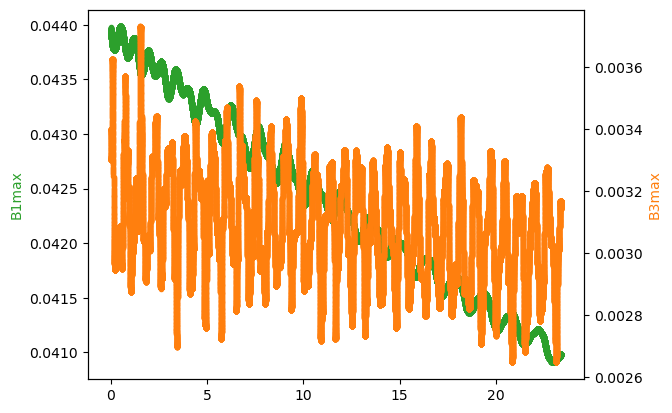

In [19]:
fig, ax1 = plt.subplots()

vals1 = read_log(
    "./amrvac/output/discrete_alfven__c.log"
)
vals2 = vals1

field1 = "B1max"
ax1.scatter(vals1["global_time"], vals1[field1], color="C2", marker='.')
ax1.set_ylabel(field1, color="C2")

field2 = "B3max"
ax2 = ax1.twinx()
ax2.scatter(vals2["global_time"], vals2[field2], color="C1", marker='.')
ax2.set_ylabel(field2, color="C1")

plt.show()

yt : [INFO     ] 2026-09-22 12:57:44,828 Parameters: current_time              = 23.55
yt : [INFO     ] 2026-09-22 12:57:44,829 Parameters: domain_dimensions         = [256 256 128]
yt : [INFO     ] 2026-09-22 12:57:44,830 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-22 12:57:44,831 Parameters: domain_right_edge         = [1.         6.28318531 6.28318531]
yt : [INFO     ] 2026-09-22 12:57:44,832 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-09-22 12:57:44,961 Using full MHD energy for thermal pressure.


yt geometry: polar
domain: [0. 0. 0.] code_length -> [1.         6.28318531 6.28318531] code_length


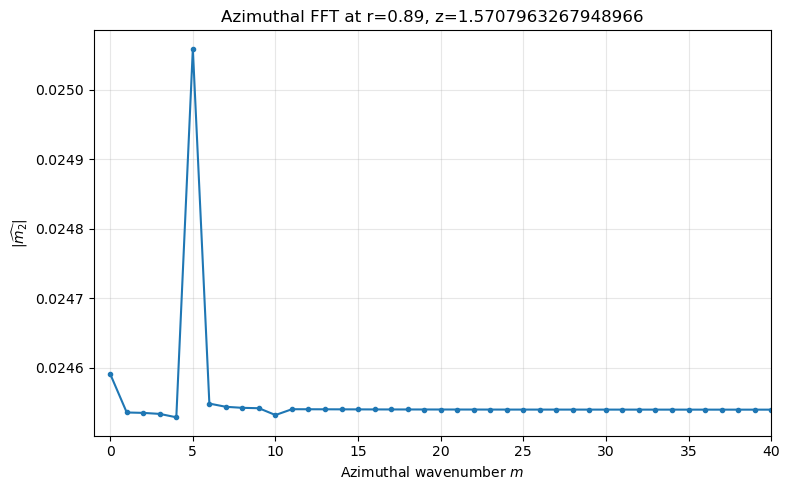

In [21]:
### this code snippet can be used to perform Fourier analysis of the azimuthal and vertical wavenumbers

field = ('amrvac', 'rho')
ds = yt.load('./amrvac/output/discrete_alfven_0471.dat')

# Sample m2 around a ring at fixed radius and z-position
radius = 0.89
z_position = 0.25 * (
    float(ds.domain_left_edge[2]) + float(ds.domain_right_edge[2])
)
n_theta = 255
geometry = str(getattr(ds, "geometry", "")).lower()
print(f"yt geometry: {geometry}")
print(f"domain: {ds.domain_left_edge} -> {ds.domain_right_edge}")

_original_point = ds.point

if "cartesian" in geometry:
    def cylindrical_point(coords):
        r, phi_value, z = map(float, coords)
        return _original_point((
            r * np.cos(phi_value),
            r * np.sin(phi_value),
            z,
        ))

    ds.point = cylindrical_point
phi_min = 0
phi_max = ds.domain_right_edge[1]
phi_period = phi_max - phi_min
phi = phi_min + phi_period * np.arange(n_theta) / n_theta

values = np.empty(phi.shape[0], dtype=float)
for i, angle in enumerate(phi[:-1]):
    point = ds.point((radius, float(angle), z_position))
    val = np.asarray(point[field]).reshape(-1)
    values[i] = val[0]

# Fourier transform in the azimuthal direction
fft_values = np.fft.fft(values)
wavenumbers = 2.0 * np.pi * np.fft.fftfreq(n_theta, d=phi_period / n_theta)
amplitudes = np.abs(fft_values) / n_theta

# Plot non-negative azimuthal wavenumbers
positive = wavenumbers >= 0
order = np.argsort(wavenumbers[positive])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    wavenumbers[positive][order],
    amplitudes[positive][order],
    marker="o",
    ms=3,
)
ax.set_xlabel(r"Azimuthal wavenumber $m$")
ax.set_ylabel(r"$|\widehat{m_2}|$")
ax.set_title(f"Azimuthal FFT at r={radius}, z={z_position}")
ax.grid(True, alpha=0.3)
ax.set_xlim(-1,40)
plt.tight_layout()
plt.show()

yt : [INFO     ] 2026-09-22 12:57:48,776 Parameters: current_time              = 23.55
yt : [INFO     ] 2026-09-22 12:57:48,777 Parameters: domain_dimensions         = [256 256 128]
yt : [INFO     ] 2026-09-22 12:57:48,778 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-22 12:57:48,780 Parameters: domain_right_edge         = [1.         6.28318531 6.28318531]
yt : [INFO     ] 2026-09-22 12:57:48,782 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-09-22 12:57:49,147 Using full MHD energy for thermal pressure.


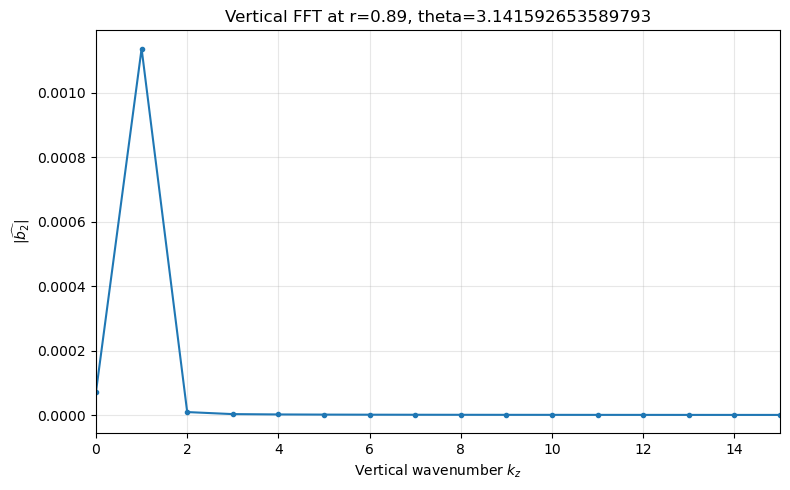

In [22]:
field = ("amrvac", "rho")
ds = yt.load("./amrvac/output/discrete_alfven_0471.dat")

radius = 0.89
phi_value = np.pi
n_z = 127

z_min = float(ds.domain_left_edge[2])
z_max = float(ds.domain_right_edge[2])
dz = (z_max - z_min) / n_z
z = z_min + (z_max - z_min) * np.arange(n_z) / n_z

values = np.empty(z.shape[0], dtype=float)
for i, z_val in enumerate(z):
    point = ds.point((radius, phi_value, float(z_val)))
    val = np.asarray(point[field]).reshape(-1)
    values[i] = val[0]

fft_values = np.fft.fft(values)
k_z = 2.0 * np.pi * np.fft.fftfreq(n_z, d=dz)
amplitudes = np.abs(fft_values) / n_z
positive = k_z >= 0
order = np.argsort(k_z[positive])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    k_z[positive][order],
    amplitudes[positive][order],
    marker='o',
    ms=3,
)
ax.set_xlabel(r"Vertical wavenumber $k_z$")
ax.set_ylabel(r"$|\widehat{b_2}|$")
ax.set_title(f"Vertical FFT at r={radius}, theta={phi_value}")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 15)
plt.tight_layout()
plt.show()